<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/ANN%2CCNN%2Cmnimst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
## importing Important Libraries
import pandas as pd ## for Data Frame Creation and Data Manipulation

import numpy as np ## for mathematical calculation

import matplotlib.pyplot as plt ## For data visualization

import seaborn as sns##For Advanced Data Visualization

import warnings

warnings.filterwarnings("ignore") ##For ignoring warnings

In [32]:
from sklearn.preprocessing import StandardScaler, LabelEncoder ##For data preprocessing
from sklearn.model_selection import train_test_split

In [33]:
from tensorflow.keras.models import Sequential ## we import a sequential so that we can go layer by layer.
from tensorflow.keras.layers import Dense ## For adding neurons in our architecture
from tensorflow.keras.layers import Dropout ## For avoiding overfitting
from tensorflow.keras.callbacks import EarlyStopping ## For avoiding overfitting
from tensorflow.keras.layers import Conv2D ## For feature extraction
from tensorflow.keras.layers import MaxPooling2D ##Maxpooling reduces size.
from tensorflow.keras.layers import Flatten ##To flatten the data
from tensorflow.keras.utils import to_categorical ##So that the output of the data can be converted by one-hot encoding

In [34]:
## Loading the data
df=pd.read_csv('/content/sample_data/mnist_train_small.csv')
df_test=pd.read_csv('/content/sample_data/mnist_test.csv')

In [35]:
df

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19995,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19996,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19997,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
df_test

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9995,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
## Preprocessing the data


### Separate labels and features, then normalize pixel values

In [39]:
# Separate labels and features for training data
X_train = df.drop(df.columns[0], axis=1)
y_train = df[df.columns[0]]

# Separate labels and features for testing data
X_test = df_test.drop(df_test.columns[0], axis=1)
y_test = df_test[df_test.columns[0]]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (19999, 784)
Shape of y_train: (19999,)
Shape of X_test: (9999, 784)
Shape of y_test: (9999,)


In [40]:
# Normalize the pixel values by dividing by 255
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel values normalized.")
print(f"Max value in X_train after normalization: {X_train.max().max()}")
print(f"Max value in X_test after normalization: {X_test.max().max()}")

Pixel values normalized.
Max value in X_train after normalization: 1.0
Max value in X_test after normalization: 1.0


### Reshape input data and one-hot encode labels

In [43]:
# Reshape the input data for CNN
X_train = X_train.values.reshape(-1, 28, 28)
X_test = X_test.values.reshape(-1, 28, 28)

print(f"New shape of X_train: {X_train.shape}")
print(f"New shape of X_test: {X_test.shape}")

New shape of X_train: (19999, 28, 28)
New shape of X_test: (9999, 28, 28)


In [44]:
# One-hot encode the labels
num_classes = 10 # MNIST has digits 0-9
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"New shape of y_train: {y_train.shape}")
print(f"New shape of y_test: {y_test.shape}")

New shape of y_train: (19999, 10)
New shape of y_test: (9999, 10)


In [82]:
perceptron=Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

In [89]:
perceptron.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [103]:
history_perceptron = perceptron.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test),batch_size=32,verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9946 - loss: 0.0202 - val_accuracy: 0.9690 - val_loss: 0.1081
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9963 - loss: 0.0149 - val_accuracy: 0.9703 - val_loss: 0.1126
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9984 - loss: 0.0095 - val_accuracy: 0.9698 - val_loss: 0.1153
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9981 - loss: 0.0098 - val_accuracy: 0.9685 - val_loss: 0.1301
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9978 - loss: 0.0100 - val_accuracy: 0.9677 - val_loss: 0.1322
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9991 - loss: 0.0057 - val_accuracy: 0.9698 - val_loss: 0.1255
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9999 - loss: 0.0026 - val_accuracy: 0.9720 - val_loss: 0.1194
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9999 - loss: 0.0023 - val_accuracy: 0.

always consider the validation accuracy, since accuracy is 'the model says he knows. Validation accuracy is how the data is performing on the testing data.

In [104]:
acc_per=perceptron.evaluate(X_test,y_test,verbose=1)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9721 - loss: 0.1239


In [105]:
acc_per

0.9720972180366516

### ANN

In [94]:
ann=Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [95]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [96]:
history_ann = ann.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test),batch_size=32,verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8857 - loss: 0.3897 - val_accuracy: 0.9300 - val_loss: 0.2225
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9509 - loss: 0.1635 - val_accuracy: 0.9485 - val_loss: 0.1840
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9678 - loss: 0.1041 - val_accuracy: 0.9562 - val_loss: 0.1400
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9754 - loss: 0.0770 - val_accuracy: 0.9634 - val_loss: 0.1194
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9841 - loss: 0.0535 - val_accuracy: 0.9626 - val_loss: 0.1245
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9874 - loss: 0.0422 - val_accuracy: 0.9658 - val_loss: 0.1225
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9902 - loss: 0.0321 - val_accuracy: 0.9681 - val_loss: 0.1182
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9917 - loss: 0.0259 - val_accuracy: 0.

In [97]:
ann.evaluate(X_test,y_test,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9669 - loss: 0.1445


[0.14446324110031128, 0.9668967127799988]

In [98]:
acc_ann=ann.evaluate(X_test,y_test,verbose=1)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9669 - loss: 0.1445


In [99]:
acc_ann

0.9668967127799988

## CNN

In [100]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [101]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

In [74]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [80]:
history_cnn = cnn.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32, verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9987 - loss: 0.0049 - val_accuracy: 0.9846 - val_loss: 0.0592
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9969 - loss: 0.0094 - val_accuracy: 0.9868 - val_loss: 0.0551
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 0.9882 - val_loss: 0.0508
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9986 - loss: 0.0043 - val_accuracy: 0.9875 - val_loss: 0.0522
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 0.9877 - val_loss: 0.0534
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9856 - val_loss: 0.0751
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9972 - loss: 0.0083 - val_accuracy: 0.9871 - val_loss: 0.0624
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9991 - loss: 0.0025 - 

In [76]:
acc_cnn=cnn.evaluate(X_test,y_test,verbose=1)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9880 - loss: 0.0434


In [77]:
acc_cnn

0.9879987835884094

In [102]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()

print("Plotting functions defined.")

Plotting functions defined.


### Perceptron Training Curves

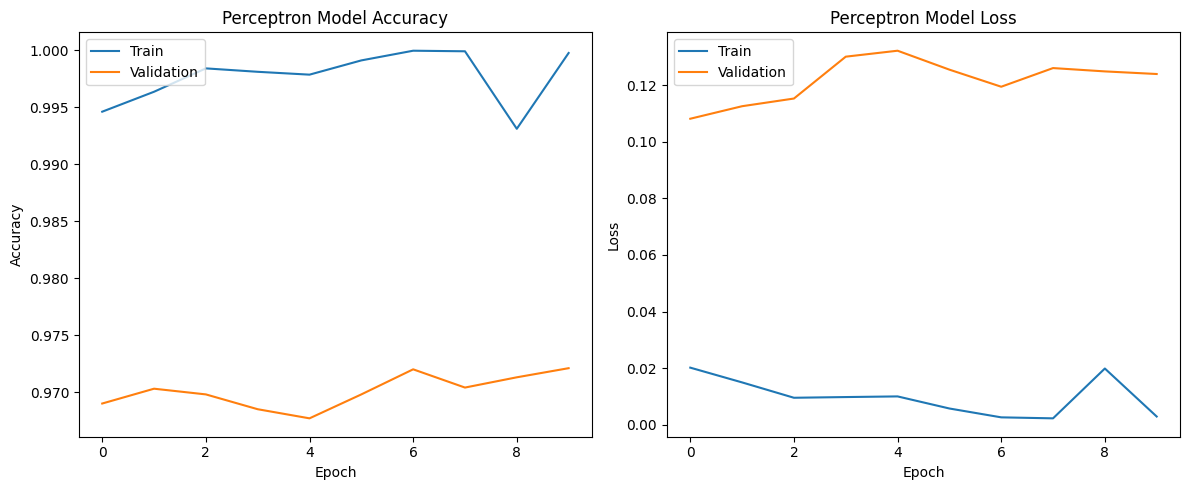

In [106]:
plot_history(history_perceptron, 'Perceptron')

In the above accuracy curve for perceptron, the curve is going up, which is fine, but accuracy is going up and down for multiple epochs, so it is not giving proper results. Similarly, for perceptron loss, this curve should be going up and down, but instead of that, it's working well for the feigning, but for validation it is not good, so it is an overfitting situation.

### ANN Training Curves

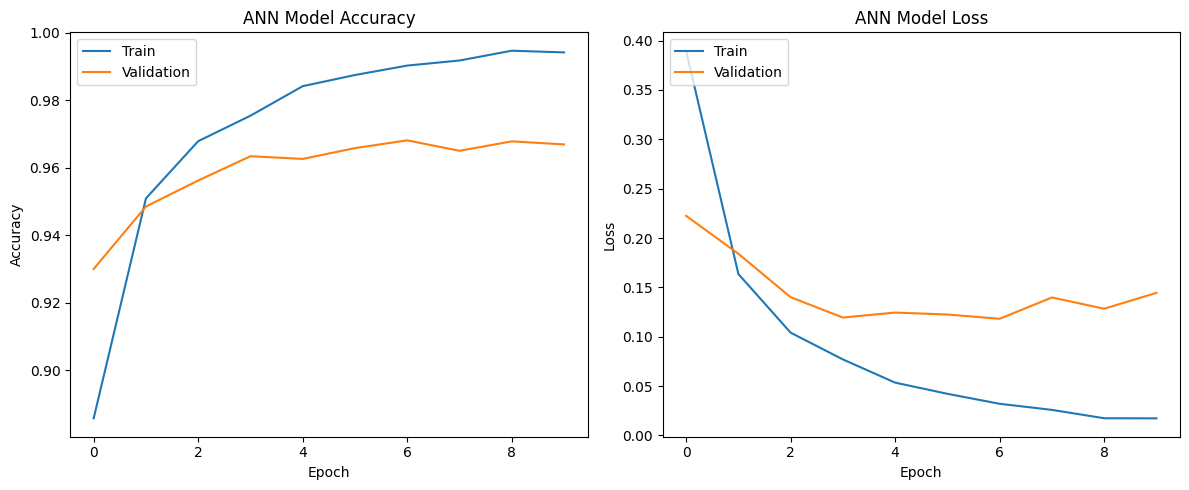

In [107]:
plot_history(history_ann, 'ANN')

For the ANN model, the model accuracy for training and validation is going up. At epoch 8, they become parallel, so it is a good accuracy curve. Similarly, for loss, both for training and validation are decreasing. It's working well for the training, but for the test, it's not as such, so it is also an overfitting problem.

### CNN Training Curves

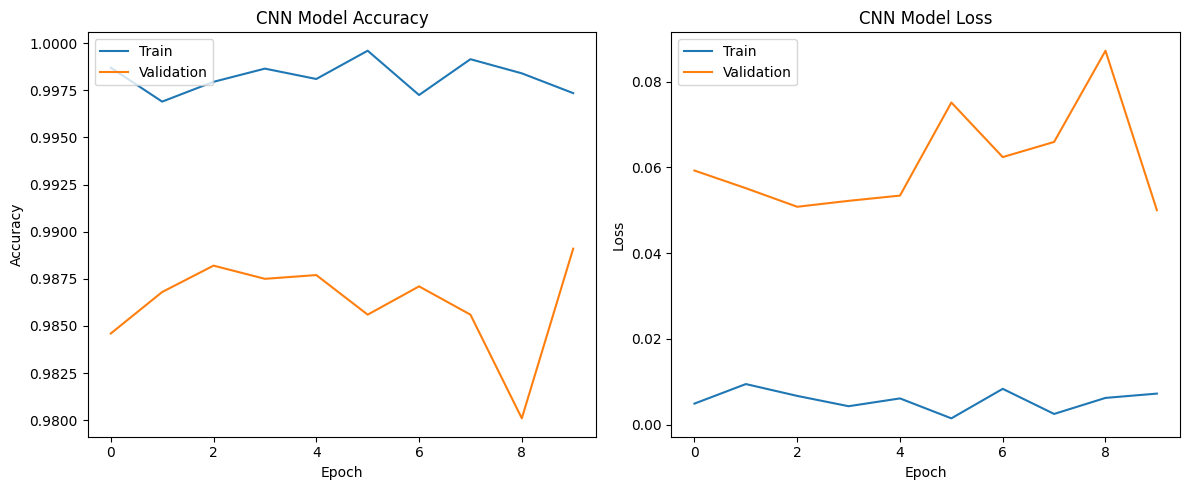

In [87]:
plot_history(history_cnn, 'CNN')

For the CNN model, as our epoch increases, the accuracy fluctuates for train and test. It should be going upward, but it's going down at the last epoch, at epoch 10. Its validation accuracy is increasing, while training accuracy is decreasing. Similarly, for the CNN model, the last repeat degrees are not decreasing so much, but for test validation, it is decreasing well, so it's good.

### Visualize Model Predictions

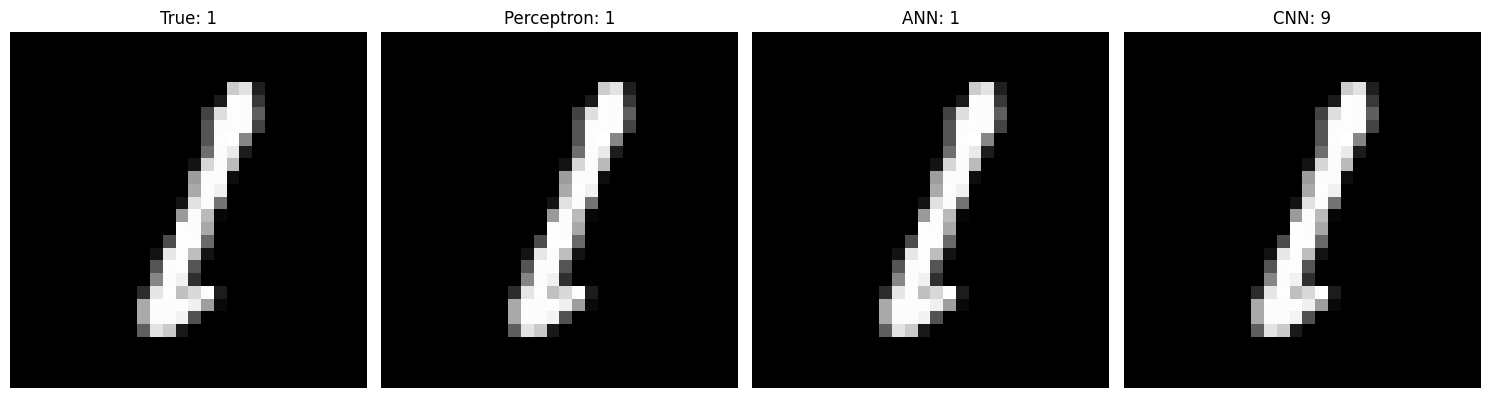

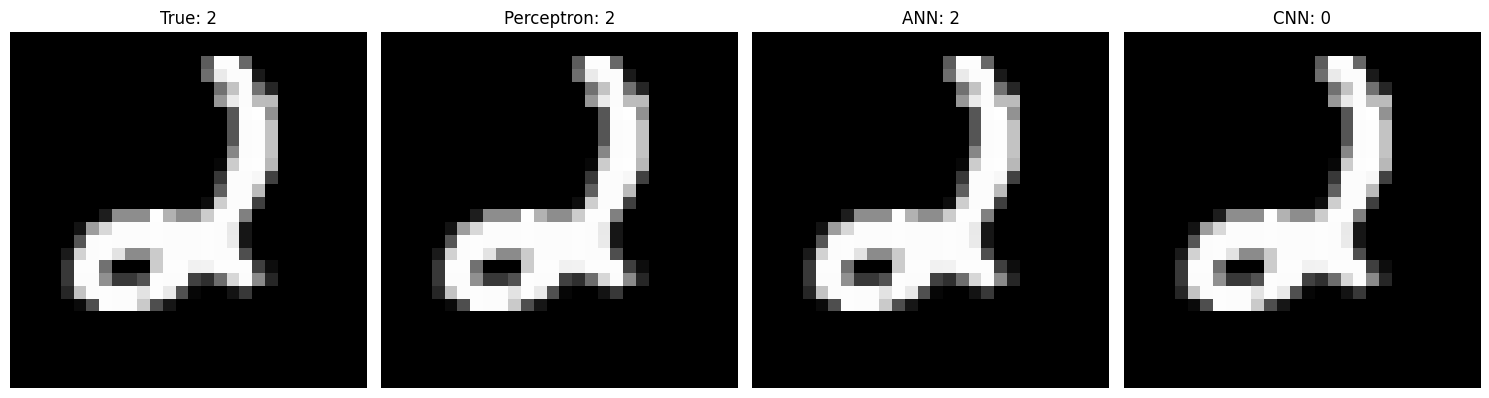

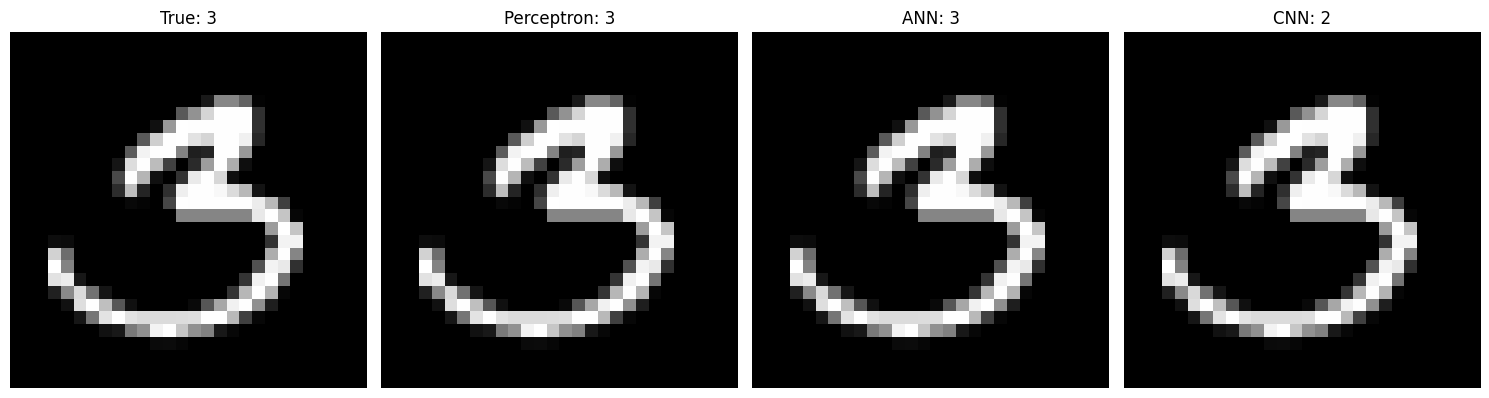

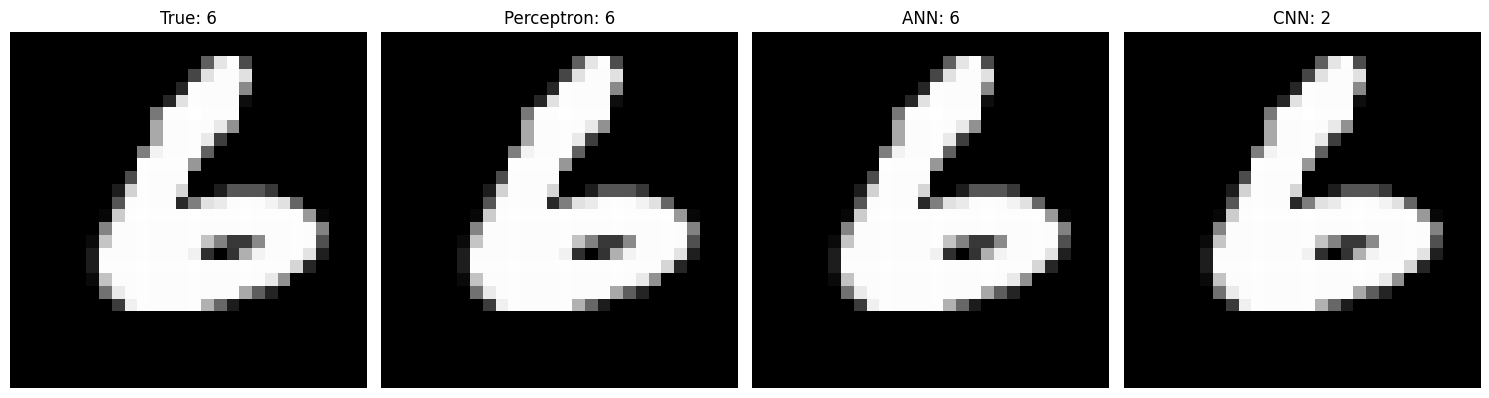

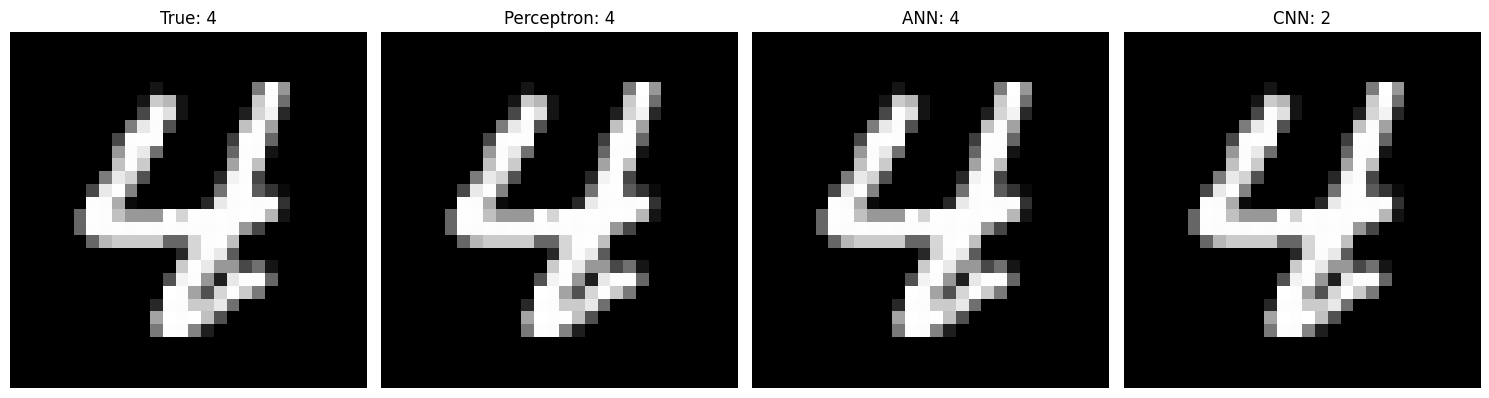

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# Select a few random samples from the test set
num_samples = 5
r_indices = np.random.choice(X_test.shape[0], num_samples, replace=False)

for i, idx in enumerate(r_indices):
    image = X_test[idx]
    true_label = np.argmax(y_test[idx])

    # Reshape image for models (if not already 4D, but it is currently)
    input_image_for_model = image.reshape(1, 28, 28, 1)

    # Get predictions
    pred_perceptron = np.argmax(perceptron.predict(input_image_for_model, verbose=0))
    pred_ann = np.argmax(ann.predict(input_image_for_model, verbose=0))
    pred_cnn = np.argmax(cnn.predict(input_image_for_model, verbose=0))

    # Plot the images and predictions side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    # Original Image with True Label
    axes[0].imshow(image.reshape(28, 28), cmap='gray')
    axes[0].set_title(f"True: {true_label}")
    axes[0].axis('off')

    # Perceptron Prediction
    axes[1].imshow(image.reshape(28, 28), cmap='gray')
    axes[1].set_title(f"Perceptron: {pred_perceptron}")
    axes[1].axis('off')

    # ANN Prediction
    axes[2].imshow(image.reshape(28, 28), cmap='gray')
    axes[2].set_title(f"ANN: {pred_ann}")
    axes[2].axis('off')

    # CNN Prediction
    axes[3].imshow(image.reshape(28, 28), cmap='gray')
    axes[3].set_title(f"CNN: {pred_cnn}")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

### Test Accuracy Comparison

In [110]:
print(f"Perceptron Test Accuracy: {acc_per:.4f}")
print(f"ANN Test Accuracy: {acc_ann:.4f}")
print(f"CNN Test Accuracy: {acc_cnn:.4f}")

Perceptron Test Accuracy: 0.9721
ANN Test Accuracy: 0.9669
CNN Test Accuracy: 0.9880


### Confusion Matrix for the Model with Most Errors (ANN)

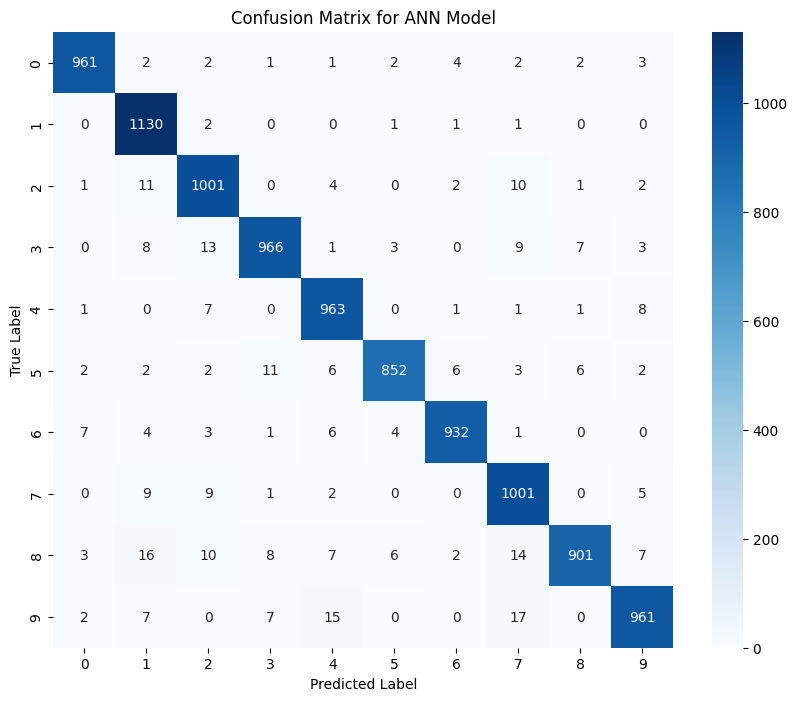

In [113]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the ANN model
y_pred_ann_one_hot = ann.predict(X_test, verbose=0)
y_pred_ann = np.argmax(y_pred_ann_one_hot, axis=1)

# Convert y_test back to single labels from one-hot encoding
y_test_labels = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm_ann = confusion_matrix(y_test_labels, y_pred_ann)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for ANN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()